In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pushd "/content/drive/MyDrive/MSSP607/Assignments"

/content/drive/MyDrive/MSSP607/Assignments


['/content']

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns

In [6]:
price = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/HousingPrices.csv')

In [7]:
price.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
count,1460.000000,1201.000000,1341.000000,1460.000000,1460.000000,1460.000000,913.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,70.049958,10440.099925,6.099315,5.575342,1971.267808,1055.813801,1162.626712,346.992466,1.565068,6.517808,1.767123,472.980137,2007.815753,180921.195890
std,421.610009,24.284752,10051.013206,1.382997,1.112799,30.202904,409.495459,386.587738,436.528436,0.550916,1.625393,0.747315,213.804841,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,0.000000,334.000000,0.000000,0.000000,2.000000,0.000000,0.000000,2006.000000,34900.000000
25%,365.750000,59.000000,7500.000000,5.000000,5.000000,1954.000000,806.000000,882.000000,0.000000,1.000000,5.000000,1.000000,334.500000,2007.000000,129975.000000
50%,730.500000,69.000000,9382.000000,6.000000,5.000000,1973.000000,996.000000,1087.000000,0.000000,2.000000,6.000000,2.000000,480.000000,2008.000000,163000.000000
75%,1095.250000,80.000000,11500.000000,7.000000,6.000000,2000.000000,1286.000000,1391.250000,728.000000,2.000000,7.000000,2.000000,576.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,3206.000000,4692.000000,2065.000000,3.000000,14.000000,4.000000,1418.000000,2010.000000,755000.000000


# The mean and sd of the price of housing

In [8]:
print("Mean SalePrice:", price['SalePrice'].mean())
print("Minimum SalePrice:", price['SalePrice'].min())
print("Maximum SalePrice:", price['SalePrice'].max())
print("Standard Deviation of SalePrice:", price['SalePrice'].std())

Mean SalePrice: 180921.19589041095
Minimum SalePrice: 34900
Maximum SalePrice: 755000
Standard Deviation of SalePrice: 79442.50288288663


# histogram of the housing price

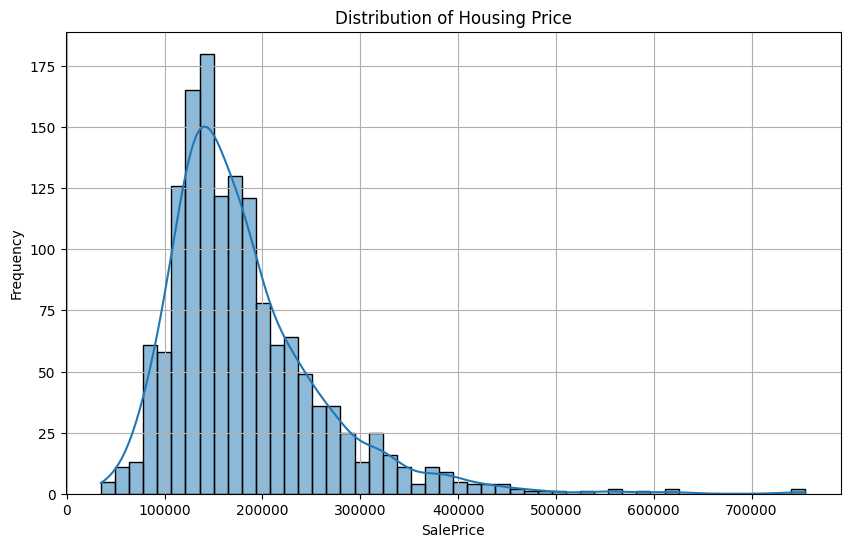

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(price['SalePrice'], bins=50, kde=True)
plt.title('Distribution of Housing Price')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Outliers that may impact the analysis?

# how to handle the outliers if identified?

In [10]:
Q1 = price['SalePrice'].quantile(0.25)
Q3 = price['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

outlier_threshold_upper = Q3 + 1.5 * IQR
outlier_threshold_lower = Q1 - 1.5 * IQR

outliers = price[(price['SalePrice'] < outlier_threshold_lower) | (price['SalePrice'] > outlier_threshold_upper)]

print(f"Number of outliers in 'SalePrice': {len(outliers)}")
display(outliers[['Id', 'SalePrice']])

Number of outliers in 'SalePrice': 61


,Id,SalePrice
11,12,345000
53,54,385000
58,59,438780
112,113,383970
151,152,372402
...,...,...
1268,1269,381000
1353,1354,410000
1373,1374,466500
1388,1389,377500


In [14]:
price_clean = price[
    (price['SalePrice']>= outlier_threshold_lower) &
    (price['SalePrice']>= outlier_threshold_upper)].copy()
print(f"Number of outliers in 'SalePrice': {len(price_clean)}")

Number of outliers in 'SalePrice': 61


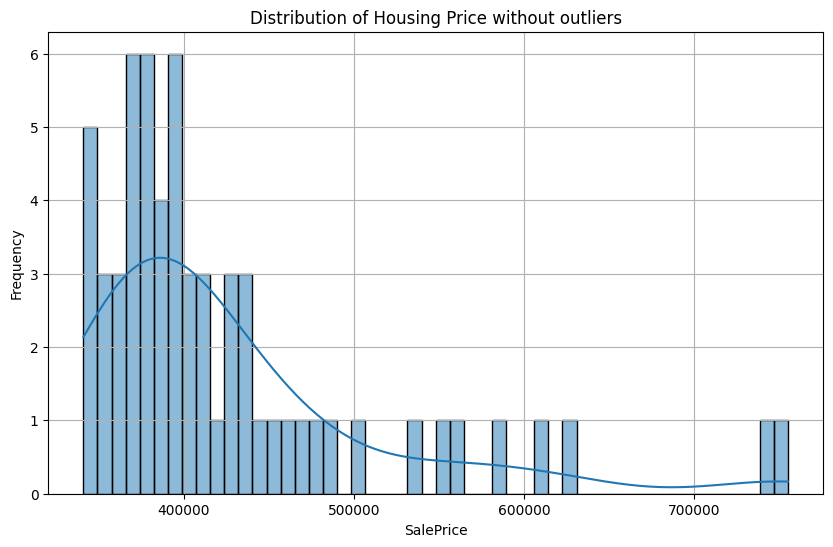

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(price_clean['SalePrice'], bins=50, kde=True)
plt.title('Distribution of Housing Price without outliers')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()